# Phase 0: Problem Understanding 🎯 Problem Statement

## บริษัท E-commerce ต้องการทำนายว่าลูกค้าคนไหนมีแนวโน้มจะ Churn (เลิกใช้บริการ) เพื่อที่จะสามารถ:
- ทำ Retention Campaign
- ลดต้นทุนการหาลูกค้าใหม่
- เพิ่ม Customer Lifetime Value (CLV)

## Objective

### สร้าง Binary Classification Model เพื่อทำนาย:

- Churn = 1 → ลูกค้ามีแนวโน้มจะเลิกใช้
- Churn = 0 → ลูกค้ายังใช้งานต่อ

# Phase 1: Data Understanding & Initial Exploration

1. โหลดข้อมูลจากไฟล์ Excel
2. ตรวจสอบขนาดข้อมูล (rows, columns)
3. ดูโครงสร้างตัวแปร (data types)
4. ตรวจสอบ Missing Values
5. วิเคราะห์ Target Variable (Churn distribution)
6. ตรวจสอบ class imbalance

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [62]:
df = pd.read_excel('/kaggle/input/ecommerce-customer-churn-analysis-and-prediction/E Commerce Dataset.xlsx', sheet_name = 'E Comm')

# 5 แถวแรก 
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [63]:
df.shape

(5630, 20)

- 5630 customer in dataset
- 20 columns features and target

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [65]:
df.isnull().sum().sort_values(ascending=False)

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
CustomerID                       0
PreferredLoginDevice             0
Churn                            0
PreferredPaymentMode             0
CityTier                         0
SatisfactionScore                0
PreferedOrderCat                 0
NumberOfDeviceRegistered         0
Gender                           0
Complain                         0
NumberOfAddress                  0
MaritalStatus                    0
CashbackAmount                   0
dtype: int64

- Missing values มีอยู่ประมาณ 4–5% ของ dataset

- ไม่มี column ไหน missing เกิน 10%

- ถือว่า manageable

- มีแนวโน้มว่าเป็น missing แบบ random (ต้องตรวจสอบเพิ่มเติมใน EDA Phase)

In [66]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


## Insight:

Dataset มี Class Imbalance

- Majority class = Non-Churn

- Minority class = Churn

สัดส่วนประมาณ 83 : 17

## เนื่องจากเป็น Imbalanced Dataset:

Accuracy จะไม่ใช่ metric ที่ดี

ควรใช้:

- Precision

- Recall

- F1-score

- ROC-AUC

และอาจใช้เทคนิค:

- SMOTE

- Class Weight

- Threshold tuning

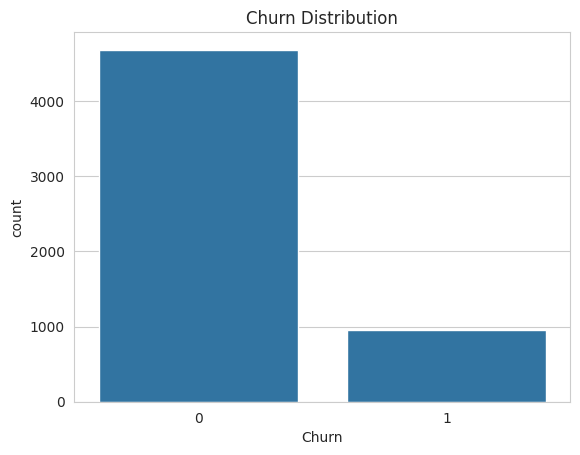

In [67]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Summary

Dataset มีคุณภาพดี:

- ข้อมูลครบถ้วน

- Missing ไม่รุนแรง

- Target ชัดเจน

ความท้าทายหลักของโปรเจกต์นี้คือ:

🔴 Handling Class Imbalance เพื่อทำนาย churn ให้แม่นยำโดยไม่ bias ไปทาง majority class

# 🔷 Phase 2: Exploratory Data Analysis (EDA)

## วิเคราะห์ความสัมพันธ์ระหว่างแต่ละ Feature กับ Churn

1. ดู Distribution ของตัวแปรสำคัญ

2. หา Pattern ของลูกค้าที่มีแนวโน้ม Churn

3. หา Feature ที่อาจมี Predictive Power สูง

🎯 เป้าหมายคือเข้าใจ "พฤติกรรมของลูกค้าที่ Churn"

## Section 1: Correlation Analysis (Numerical Features)

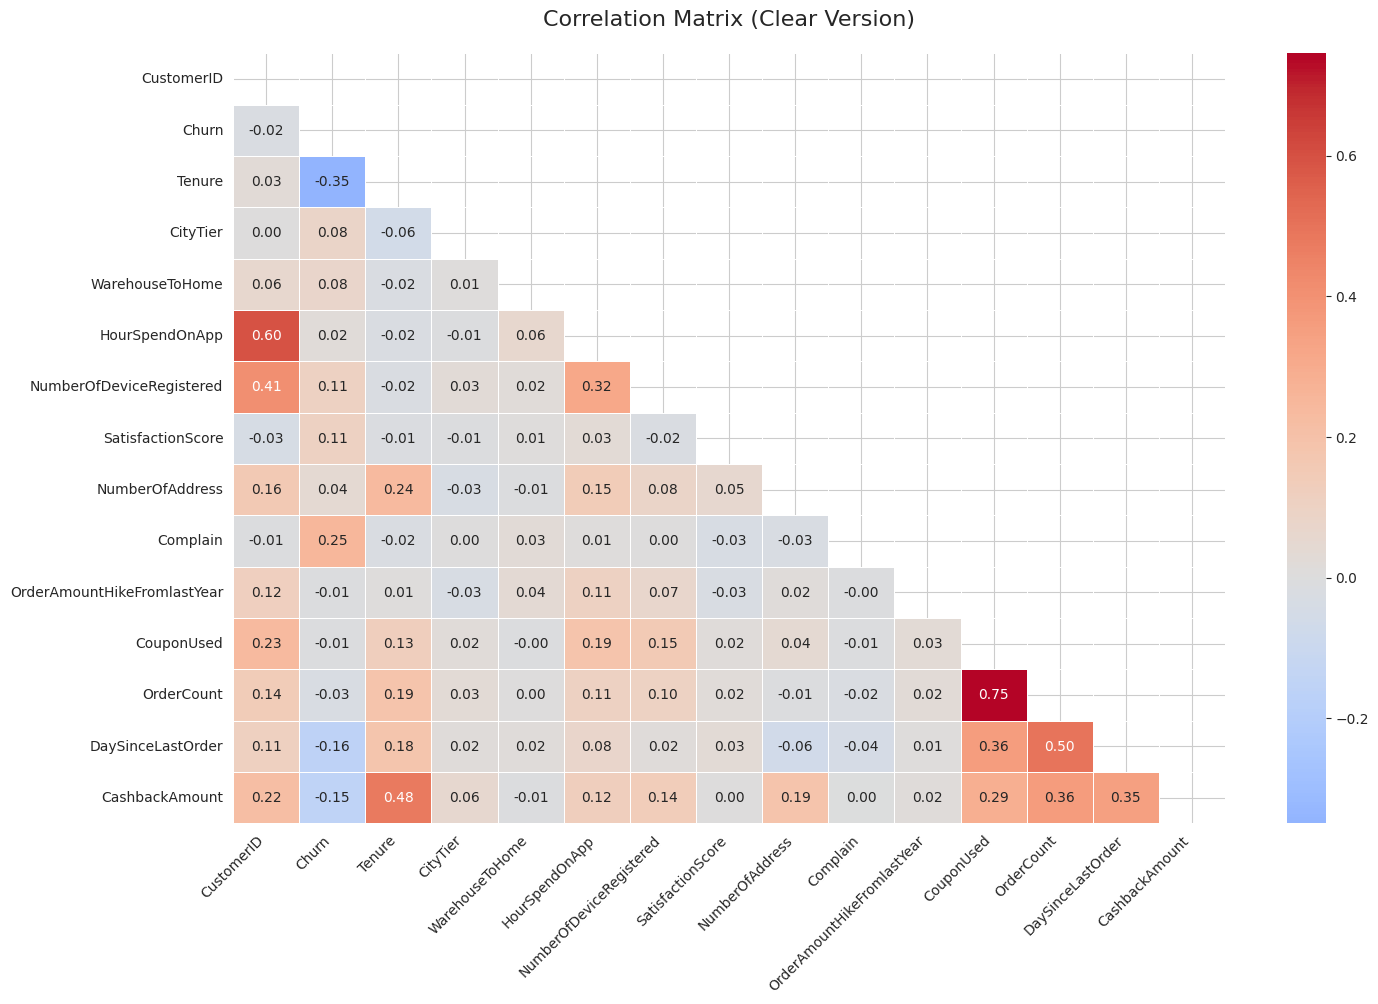

In [68]:
# ตั้งค่าขนาดภาพให้ใหญ่ขึ้นพอที่จะรองรับตัวเลข
plt.figure(figsize=(16, 10))

# คำนวณ Correlation
corr = df.corr(numeric_only=True)

# สร้าง Mask เพื่อปิดสามเหลี่ยมด้านบน (เพราะข้อมูลมันซ้ำกันกับด้านล่าง) 
# จะช่วยให้ดูง่ายขึ้นมาก ไม่ลายตา
mask = np.triu(np.ones_like(corr, dtype=bool))

# วาด Heatmap
sns.heatmap(corr, 
            mask=mask,           # ใช้ mask ปิดครึ่งบน
            annot=True,          # ใส่ตัวเลขกำกับ (สำคัญมากเพื่อให้ชัดเจน)
            fmt=".2f",           # ทศนิยม 2 ตำแหน่ง
            cmap="coolwarm",     # ไล่สีจากฟ้าไปแดง
            center=0,            # ให้ 0 เป็นสีกลาง (สีขาว/เทา)
            linewidths=0.5,      # เพิ่มเส้นตัดระหว่างช่อง
            annot_kws={"size": 10}) # ปรับขนาดตัวเลขในช่อง

plt.title("Correlation Matrix (Clear Version)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # หมุนชื่อแกน X เพื่อไม่ให้ทับกัน
plt.show()


In [69]:
corr_with_churn = corr['Churn'].sort_values(ascending=False)
corr_with_churn

Churn                          1.000000
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
HourSpendOnApp                 0.018675
CouponUsed                    -0.008264
OrderAmountHikeFromlastYear   -0.010058
CustomerID                    -0.019083
OrderCount                    -0.028697
CashbackAmount                -0.154118
DaySinceLastOrder             -0.160757
Tenure                        -0.349408
Name: Churn, dtype: float64

## Strongest Correlations with Churn


- Tenure → -0.349

- Complaint → +0.250

- DaySinceLastOrder → -0.161

- CashbackAmount → -0.154

- NumberOfDeviceRegistered → +0.108

- SatisfactionScore → +0.105

## Key Interpretation
### Tenure (สำคัญที่สุด)

Correlation เชิงลบสูง (-0.349)

ลูกค้าที่อยู่กับบริษัทนาน → มีโอกาส churn ต่ำ

ลูกค้าใหม่ → churn สูงมาก

🎯 Business Insight:

ช่วง 0–3 เดือนแรกเป็นช่วงเสี่ยงสูง

ควรมี onboarding strategy หรือ early engagement campaign

### Complaint

Correlation เชิงบวก (+0.25)

ลูกค้าที่เคยร้องเรียนมีแนวโน้ม churn สูงกว่า

🎯 Business Insight:

Customer experience มีผลโดยตรงต่อ churn

ควรมี fast-track support หรือ retention team

### DaySinceLastOrder (Customer Inactivity)

ลูกค้าที่ไม่ได้สั่งซื้อมานาน → เสี่ยง churn สูง

🎯 Business Insight:

Inactive customer = กลุ่มเสี่ยง

ควรทำ email reminder / promotion trigger

### CashbackAmount

Correlation เชิงลบ

ลูกค้าที่ได้รับ cashback สูง → churn ต่ำกว่า

🎯 Business Insight:

Reward program ช่วยลด churn

Loyalty program มีผลเชิงบวก


## Section 2: Numerical Features vs Churn

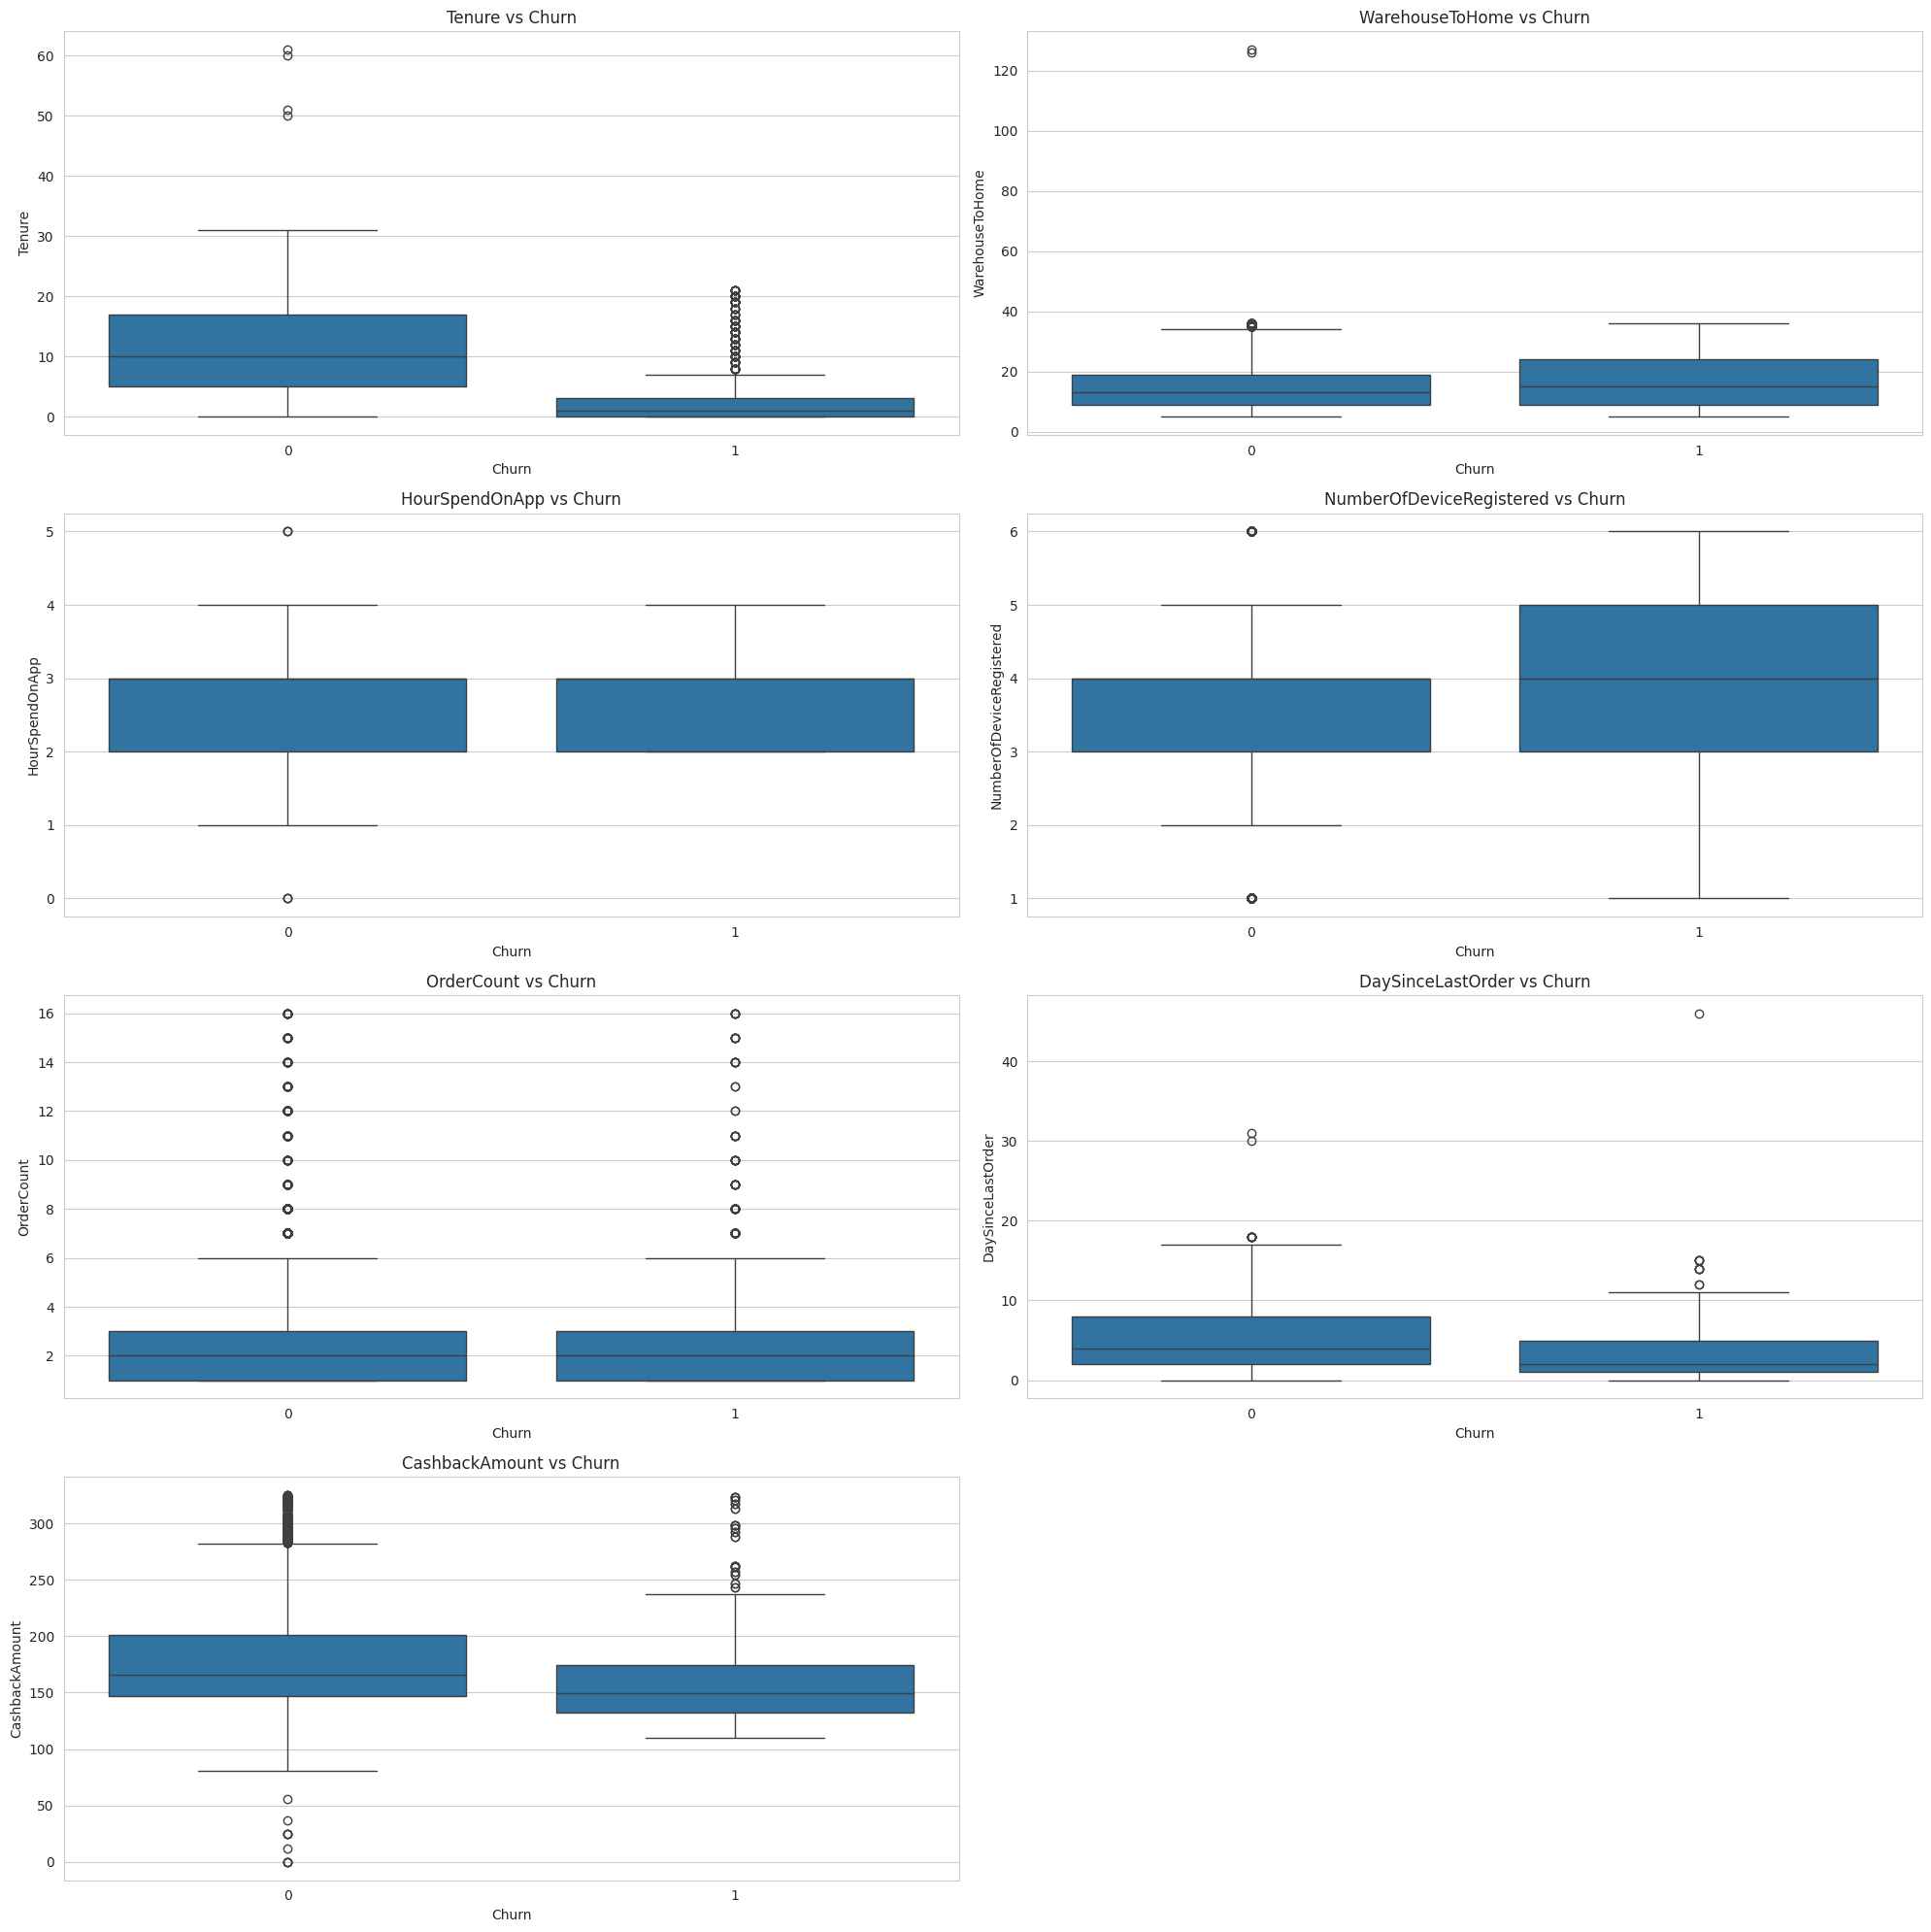

In [70]:
# สร้าง Figure และ Axes ขนาด 4 แถว 4 คอลัมน์
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))

# ปรับ axes ให้เป็น list 1 มิติเพื่อให้ง่ายต่อการวนลูป
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

# ซ่อน Axes ช่องที่เหลือที่ไม่ได้ใช้งาน (เนื่องจากมีแค่ 7 กราฟ แต่มี 16 ช่อง)
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## จากการวิเคราะห์ Boxplot:

ลูกค้า churn มี Tenure ต่ำชัดเจน

ลูกค้า churn มี engagement ต่ำกว่า

ลูกค้าที่ active มากกว่า (สั่งบ่อย / ได้ cashback สูง) มีแนวโน้มอยู่ต่อ

## Section 3: Categorical Features vs Churn

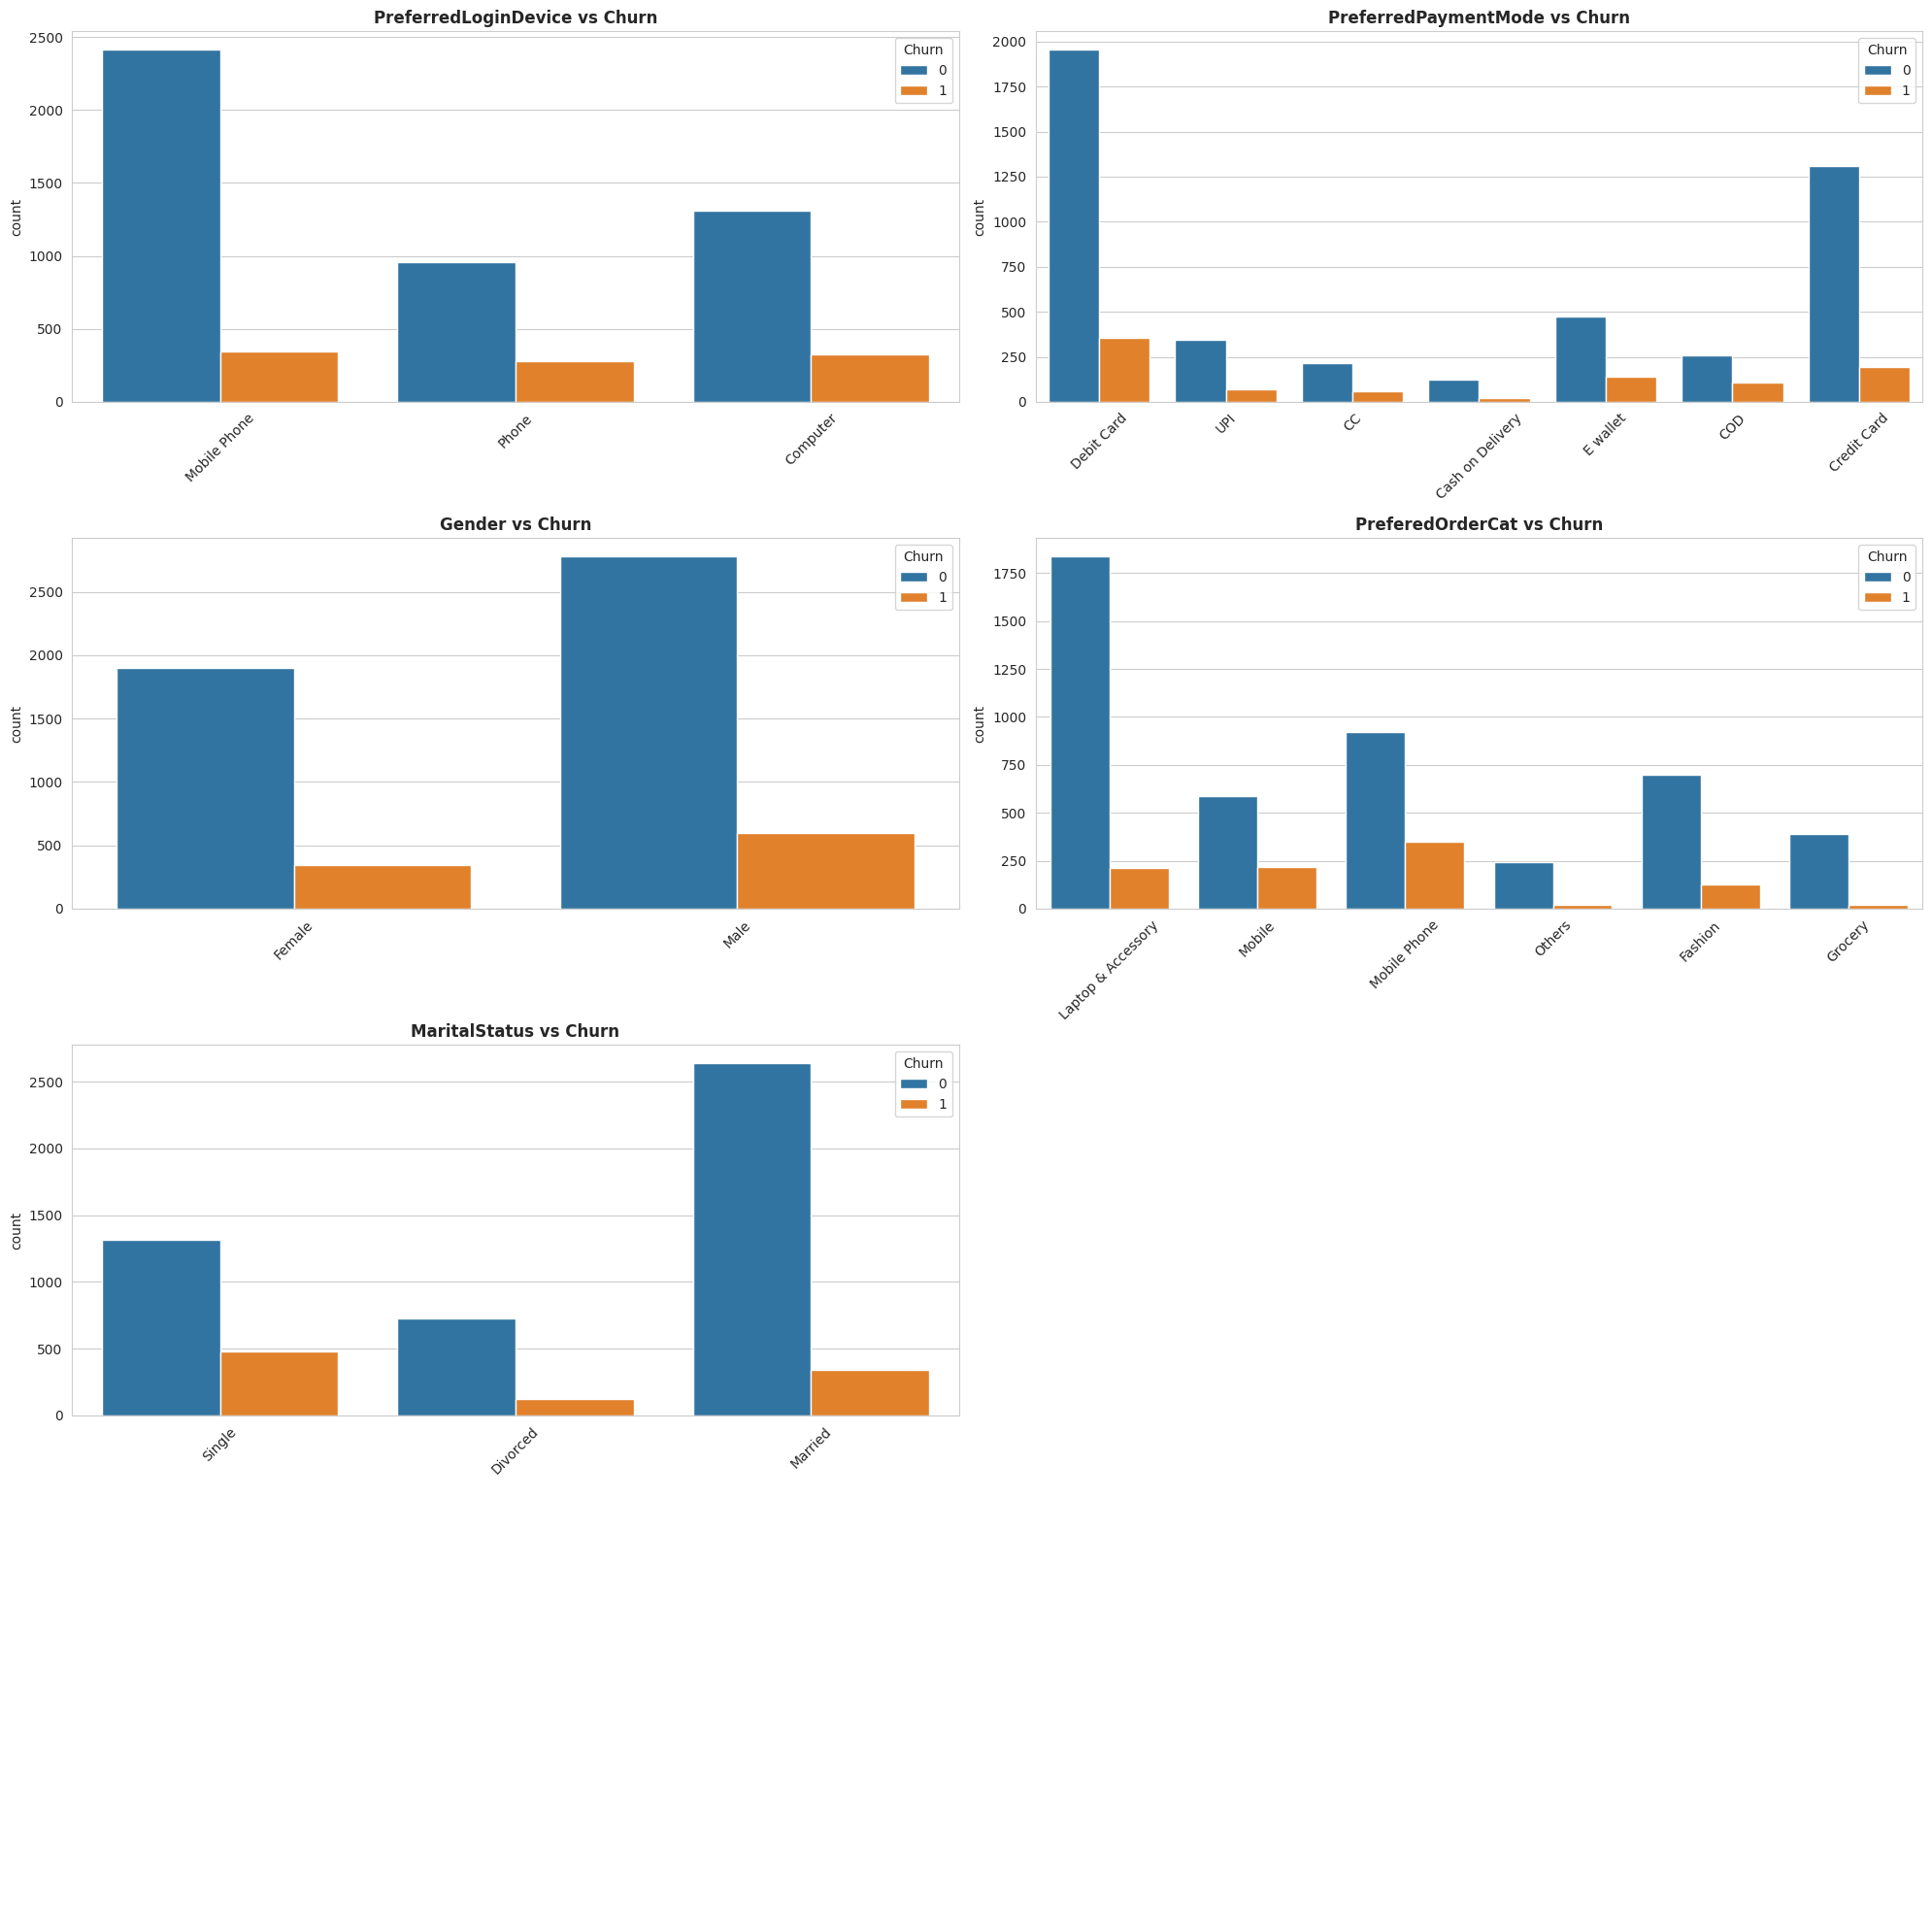

In [71]:
cat_cols = df.select_dtypes(include='object').columns

# สร้าง Figure ขนาด 4x4
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # วาด Countplot ลงในช่อง axes[i]
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i])
    
    # ตั้งค่าหัวข้อและการหมุนชื่อแกน X
    axes[i].set_title(f"{col} vs Churn", fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45) 
    axes[i].set_xlabel('') # ลบชื่อแกน x ออกเพื่อลดความแออัด
    
# ซ่อนช่องที่เหลือที่ไม่มีข้อมูล
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

# ปรับระยะห่างระหว่างกราฟไม่ให้ทับกัน
plt.tight_layout()
plt.show()

🔹 PreferredLoginDevice

Computer มี churn rate สูงกว่าเล็กน้อย

🔹 PreferredPaymentMode

COD และ E-wallet มี churn สูงกว่า Debit Card เล็กน้อย

🔹 Gender

Male churn สูงกว่า Female เล็กน้อย|

## Section 4: Business-Oriented Insight

- ลูกค้าใหม่ churn มากกว่าลูกค้าเก่าหรือไม่?

- คนที่ไม่ได้สั่งซื้อนาน มีแนวโน้ม churn ไหม?

- ลูกค้าที่ใช้ app น้อย มีโอกาส churn มากไหม?

- Satisfaction Score มีผลไหม?

## Business-Level Story

จาก EDA สามารถสรุปได้ว่า:

- ลูกค้าใหม่ที่มี engagement ต่ำ และเคยร้องเรียน มีโอกาส churn สูงที่สุด

- ลูกค้าที่ active สั่งซื้อบ่อย และได้รับ reward มีแนวโน้มอยู่ต่อ

- พฤติกรรมลูกค้ามีผลต่อ churn อย่างชัดเจน

# Phase 3: Modeling Pipeline (Multiple Models)

- Split train/test ก่อนทุกอย่าง
- ทำ Feature Engineering
- จัดการ Missing + Encoding + Scaling
- จัดการ Class Imbalance ด้วย SMOTE (เฉพาะ train เท่านั้น)
### Train 3 Models:
- Logistic Regression
- Random Forest
- XGBoost
ทุกอย่างอยู่ใน Pipeline (กัน data leakage)

In [79]:
X = df.drop(["Churn", "CustomerID"], axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [80]:
# Feature Engineering

def add_features(df):
    df = df.copy()
    
    df["AvgOrderValue"] = df["CashbackAmount"] / (df["OrderCount"] + 1)
    df["EngagementScore"] = (
        df["HourSpendOnApp"] +
        df["OrderCount"] +
        df["CouponUsed"]
    )
    df["IsInactive"] = (df["DaySinceLastOrder"] > 15).astype(int)
    df["IsNewCustomer"] = (df["Tenure"] < 3).astype(int)
    
    return df

X_train = add_features(X_train)
X_test = add_features(X_test)


In [81]:
# Column Separation
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

### Preprocessing Pipeline

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


## Apply SMOTE

In [86]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## Define Models

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Create 3 Pipelines

In [88]:
log_model = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

rf_model = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

xgb_model = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [89]:
# train
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'Order...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [90]:
# Save Predictions for Phase 4
models = {
    "Logistic": log_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }


# Phase 4: Model Evaluation & Comparison

- เปรียบเทียบ Logistic / RandomForest / XGBoost

- ดู Precision / Recall / F1

- ดู ROC-AUC

- ดู Confusion Matrix

- Plot ROC Curve

- เลือก Best Model อย่างมีเหตุผล

In [91]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [92]:
#Classification Report
for name, model in models.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, results[name]["y_pred"]))

===== Logistic =====
              precision    recall  f1-score   support

           0       0.96      0.82      0.89       936
           1       0.49      0.83      0.61       190

    accuracy                           0.82      1126
   macro avg       0.72      0.83      0.75      1126
weighted avg       0.88      0.82      0.84      1126

===== RandomForest =====
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.94      0.87      0.91       190

    accuracy                           0.97      1126
   macro avg       0.96      0.93      0.94      1126
weighted avg       0.97      0.97      0.97      1126

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       936
           1       0.88      0.79      0.84       190

    accuracy                           0.95      1126
   macro avg       0.92      0.89      0.90      1126
weighted

In [93]:
#ROC-AUC Comparison
auc_scores = {}

for name in models.keys():
    auc = roc_auc_score(y_test, results[name]["y_prob"])
    auc_scores[name] = auc

pd.DataFrame.from_dict(
    auc_scores, orient="index", columns=["ROC-AUC"]
).sort_values("ROC-AUC", ascending=False)

,ROC-AUC
RandomForest,0.995884
XGBoost,0.979060
Logistic,0.890581


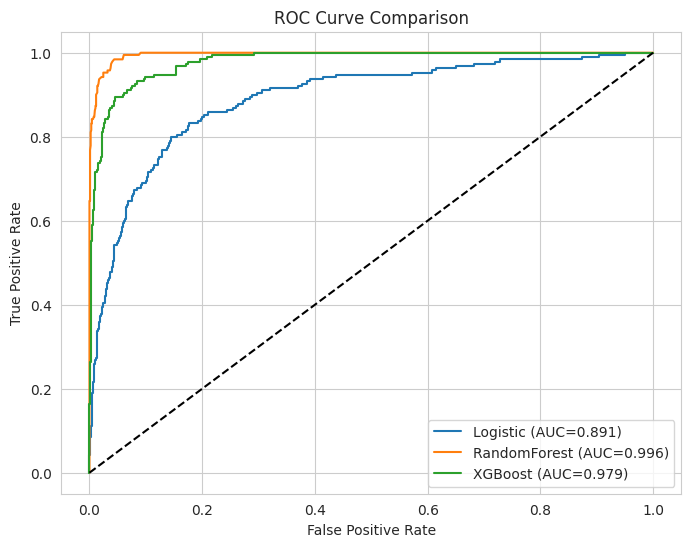

In [94]:
#Plot ROC Curves
plt.figure(figsize=(8,6))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_scores[name]:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


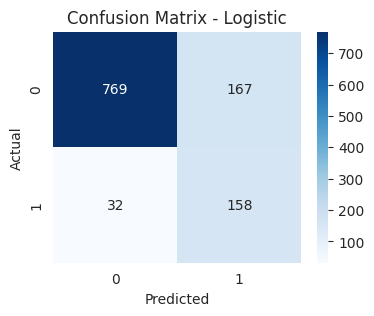

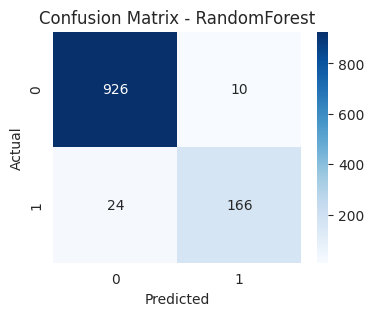

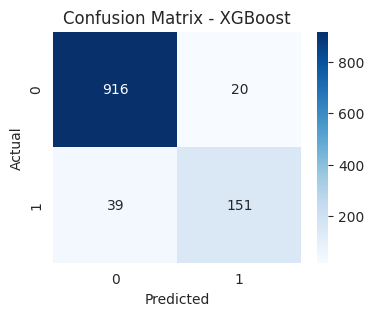

In [95]:
#Confusion Matrix
for name in models.keys():
    plt.figure(figsize=(4,3))
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# สรุปผล Model Comparison

📊 1️⃣ Logistic Regression

Accuracy: 0.82

ROC-AUC: 0.891

Recall (class 1): 0.83

Precision (class 1): 0.49

F1 (class 1): 0.61

❌ ปัญหา

False Positive เยอะมาก (167 ราย)

Precision ต่ำ → ยิงโปรมั่ว

👉 ใช้เป็น baseline ได้ แต่ไม่เหมาะ deploy

📊 2️⃣ Random Forest ⭐⭐⭐⭐⭐

Accuracy: 0.97

ROC-AUC: 0.996 (สูงมาก)

Recall (class 1): 0.87

Precision (class 1): 0.94

F1 (class 1): 0.91

Confusion Matrix

FN = 24 (พลาด churn แค่ 24 คน)

FP = 10 (ยิงโปรผิดแค่ 10 คน)

🔥 จุดแข็ง

Balance ดีมาก

Precision สูง → ไม่เปลืองงบ

Recall สูง → จับ churn ได้เยอะ

AUC เกือบ perfect separation


📊 3️⃣ XGBoost

Accuracy: 0.95

ROC-AUC: 0.979

Recall (class 1): 0.79

Precision (class 1): 0.88

F1 (class 1): 0.84

❌ จุดอ่อน

Recall ต่ำกว่า RF

FN = 39 (พลาด churn มากกว่า)

# Final Decision
✅ เลือก: Random Forest

เหตุผล:

- ROC-AUC สูงสุด
- Precision + Recall สมดุลที่สุด

- False Positive ต่ำมาก

- False Negative ต่ำมาก

- เหมาะกับธุรกิจจริง

# Phase 5: Model Interpretation & Business Strategy

- ดูว่าโมเดล Random Forest ใช้อะไรตัดสินใจ

- วิเคราะห์ Feature Importance

- แปลงผลเป็น Insight ทางธุรกิจ

- วางกลยุทธ์ Retention Campaign

- เตรียมโมเดลสำหรับ Production

In [96]:
#Feature Importance (Random Forest)

# ดึง preprocessor และ model
preprocessor = rf_model.named_steps["preprocessing"]
rf = rf_model.named_steps["classifier"]

# ดึงชื่อ feature หลัง transform
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1]["encoder"].get_feature_names_out(
    preprocessor.transformers_[1][2]
)

all_features = np.concatenate([num_features, cat_features])

# ดึง importance
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_imp.head(15)


,Feature,Importance
0,Tenure,0.141769
16,IsNewCustomer,0.121251
12,CashbackAmount,0.054578
7,Complain,0.051280
11,DaySinceLastOrder,0.047007
6,NumberOfAddress,0.044353
13,AvgOrderValue,0.041793
5,SatisfactionScore,0.039203
2,WarehouseToHome,0.037356
37,MaritalStatus_Single,0.033675


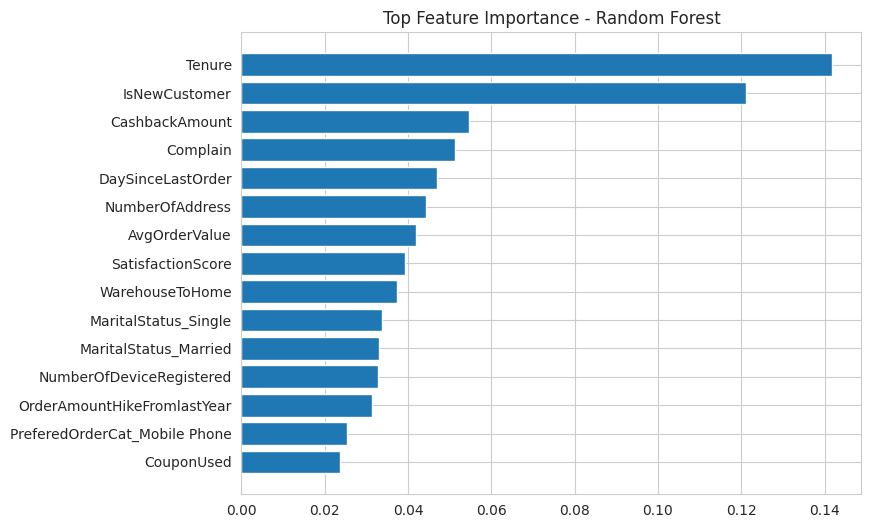

In [97]:
#Plot Top Features

top_n = 15
plt.figure(figsize=(8,6))
plt.barh(
    feat_imp["Feature"].head(top_n)[::-1],
    feat_imp["Importance"].head(top_n)[::-1]
)
plt.title("Top Feature Importance - Random Forest")
plt.show()


### Business Interpretation
โดยทั่วไป churn dataset จะเจอ feature สำคัญแบบนี้:

- DaySinceLastOrder
- Tenure
- OrderCount
- CashbackAmount
- EngagementScore
- IsInactive

### DaySinceLastOrder สูง → Churn สูง
ลูกค้าที่หายไปเกิน 15 วันมีความเสี่ยงสูง

Strategy:
- Trigger campaign อัตโนมัติ
- ส่ง coupon ภายใน 7 วัน

### Tenure ต่ำ → เสี่ยง churn
ลูกค้าใหม่ยังไม่ loyal

Strategy:
- Welcome series
- Early loyalty reward

### OrderCount ต่ำ + Engagement ต่ำ
ลูกค้าไม่ผูกพันกับ platform

Strategy:
- Gamification
- Reward engagement

In [98]:
# Threshold Optimization
#before threshold optimization recall = 0.87
y_prob = rf_model.predict_proba(X_test)[:,1]

threshold = 0.4
y_new = (y_prob > threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_new))


              precision    recall  f1-score   support

           0       0.99      0.98      0.98       936
           1       0.89      0.95      0.92       190

    accuracy                           0.97      1126
   macro avg       0.94      0.96      0.95      1126
weighted avg       0.97      0.97      0.97      1126

